In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../Data/raw/used_cars_dataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [3]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names")

for column in df.columns:
    print(f"• {column}")

DATASET OVERVIEW
Number of Rows    : 24,575
Number of Columns : 11

Column Names
• Brand
• model
• Year
• Age
• kmDriven
• Transmission
• Owner
• FuelType
• PostedDate
• AdditionInfo
• AskPrice


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         19306 non-null  str    
 1   model         14144 non-null  str    
 2   Year          19396 non-null  float64
 3   Age           18600 non-null  float64
 4   kmDriven      18344 non-null  str    
 5   Transmission  18653 non-null  str    
 6   Owner         13949 non-null  str    
 7   FuelType      19336 non-null  str    
 8   PostedDate    18355 non-null  str    
 9   AdditionInfo  24575 non-null  str    
 10  AskPrice      24575 non-null  str    
dtypes: float64(2), str(9)
memory usage: 2.1 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,19306,41,Unknown,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,14144,403,Wagon-R,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,19396.0,NaN,NaN,NaN,4118.984327,3516.311608,1900.0,2015.0,2018.0,9999.0,9999.0
Age,18600.0,NaN,NaN,NaN,7.676398,4.293379,0.0,5.0,7.0,10.0,124.0
kmDriven,18344,2303,"75,000 km",351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,18653,2,Automatic,9418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,13949,2,second,7289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FuelType,19336,5,Petrol,5447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostedDate,18355,12,Nov-24,16323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionInfo,24575,10676,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel",56,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

missing

,Missing Values,Percentage (%)
Owner,10626,43.24
model,10431,42.45
kmDriven,6231,25.36
PostedDate,6220,25.31
Age,5975,24.31
Transmission,5922,24.10
Brand,5269,21.44
FuelType,5239,21.32
Year,5179,21.07
AdditionInfo,0,0.00


In [7]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 9587


In [8]:
df["AskPrice"].describe()

count          24575
unique          1616
top       ₹ 4,50,000
freq             355
Name: AskPrice, dtype: object

# Initial Data Audit Findings #

### Dataset Overview 

The following observations were made from the dataset:

- The dataset contains both numerical and categorical variables.
- Missing values are present in multiple features and require appropriate treatment.
- Duplicate records were assessed as part of the data quality audit.
- The target variable (AskPrice) will be analysed further during exploratory data analysis.

Next we will work on understanding the distribution of variables, identifying relationships between features, and uncovering the key drivers of used car prices.

In [9]:
quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2),
    "Unique Values": df.nunique()
})

quality

,Data Type,Missing Values,Missing %,Unique Values
Brand,str,5269,21.44,41
model,str,10431,42.45,403
Year,float64,5179,21.07,36
Age,float64,5975,24.31,33
kmDriven,str,6231,25.36,2303
Transmission,str,5922,24.10,2
Owner,str,10626,43.24,2
FuelType,str,5239,21.32,5
PostedDate,str,6220,25.31,12
AdditionInfo,str,0,0.00,10676


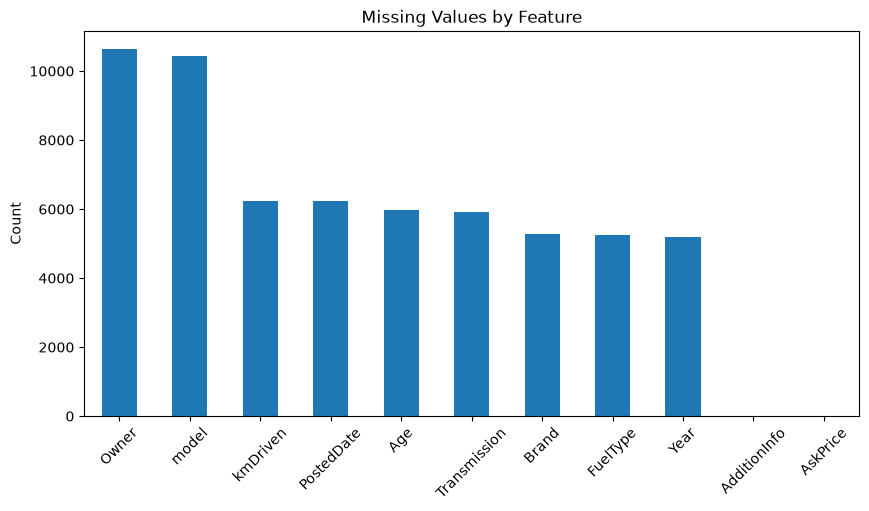

In [10]:
import matplotlib.pyplot as plt

missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values by Feature")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
missing_percent = (df.isnull().sum()/len(df)*100)\
                    .sort_values(ascending=False)

missing_percent

Owner           43.239064
model           42.445575
kmDriven        25.355036
PostedDate      25.310275
Age             24.313327
Transmission    24.097660
Brand           21.440488
FuelType        21.318413
Year            21.074262
AdditionInfo     0.000000
AskPrice         0.000000
dtype: float64

## Data Quality Observations ##

The initial quality assessment revealed that several features contain missing values.

The highest levels of missingness occur within categorical variables such as Owner and Model, while numerical features such as kmDriven also contain incomplete records.

These missing values cannot simply be removed without first evaluating their potential impact on the predictive model. Appropriate imputation strategies will therefore be considered during the preprocessing stage.

 🚗 DriveValue AI
 An Explainable Machine Learning Framework for Predicting Used Car Prices

## Capstone Project

Author: Jacqualine Makgolana

---

📌 Business Problem

Pricing a used car accurately is one of the biggest challenges in the automotive market. Factors such as age, mileage, brand, fuel type, ownership history, and transmission all influence the resale value of a vehicle.

This project aims to build a machine learning model capable of predicting the asking price of a used car while identifying the key factors that drive vehicle prices.

---

🎯 Project Objectives

- Understand the dataset
- Perform data quality assessment
- Clean and preprocess the data
- Explore patterns and relationships
- Engineer meaningful features
- Build and compare regression models
- Tune the best-performing model
- Explain model predictions
- Provide business recommendations

# Understanding the Dataset #

Before exploring relationships between variables, it is important to understand what each feature represents and how it may influence the asking price of a used vehicle.

In [ ]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

## Question 1

How are used car asking prices distributed?

Understanding the distribution of vehicle prices helps identify whether the data is normally distributed, skewed, or contains extreme values that may affect model performance.

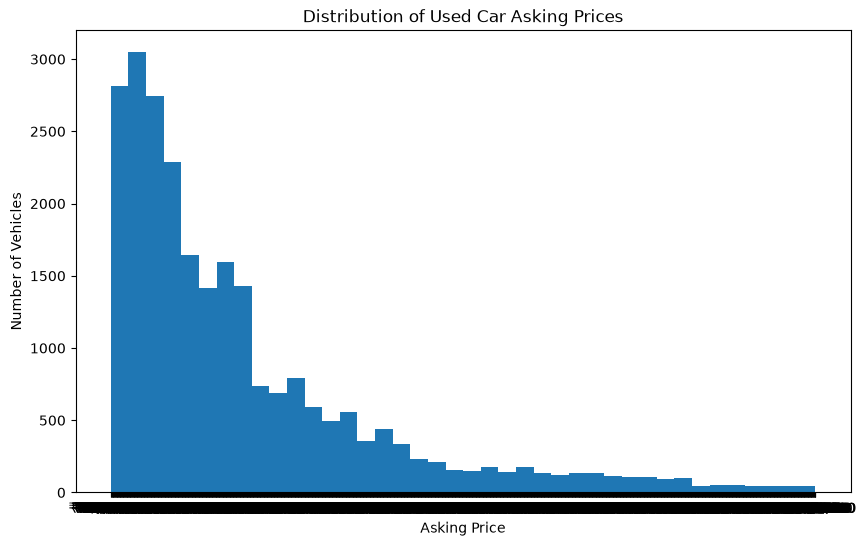

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df["AskPrice"], bins=40)

plt.title("Distribution of Used Car Asking Prices")

plt.xlabel("Asking Price")

plt.ylabel("Number of Vehicles")

plt.show()

### Interpretation

(To be completed after viewing the visualization.)

## Question 2

Which vehicle brands appear most frequently in the dataset?

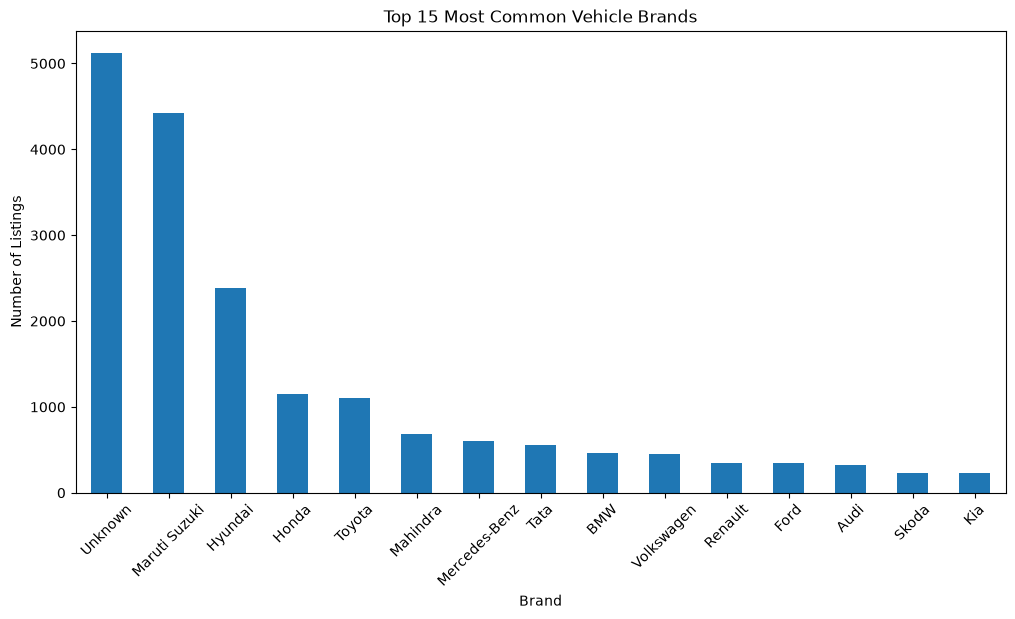

In [14]:
brand_counts = df["Brand"].value_counts().head(15)

plt.figure(figsize=(12,6))

brand_counts.plot(kind="bar")

plt.title("Top 15 Most Common Vehicle Brands")

plt.xlabel("Brand")

plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()